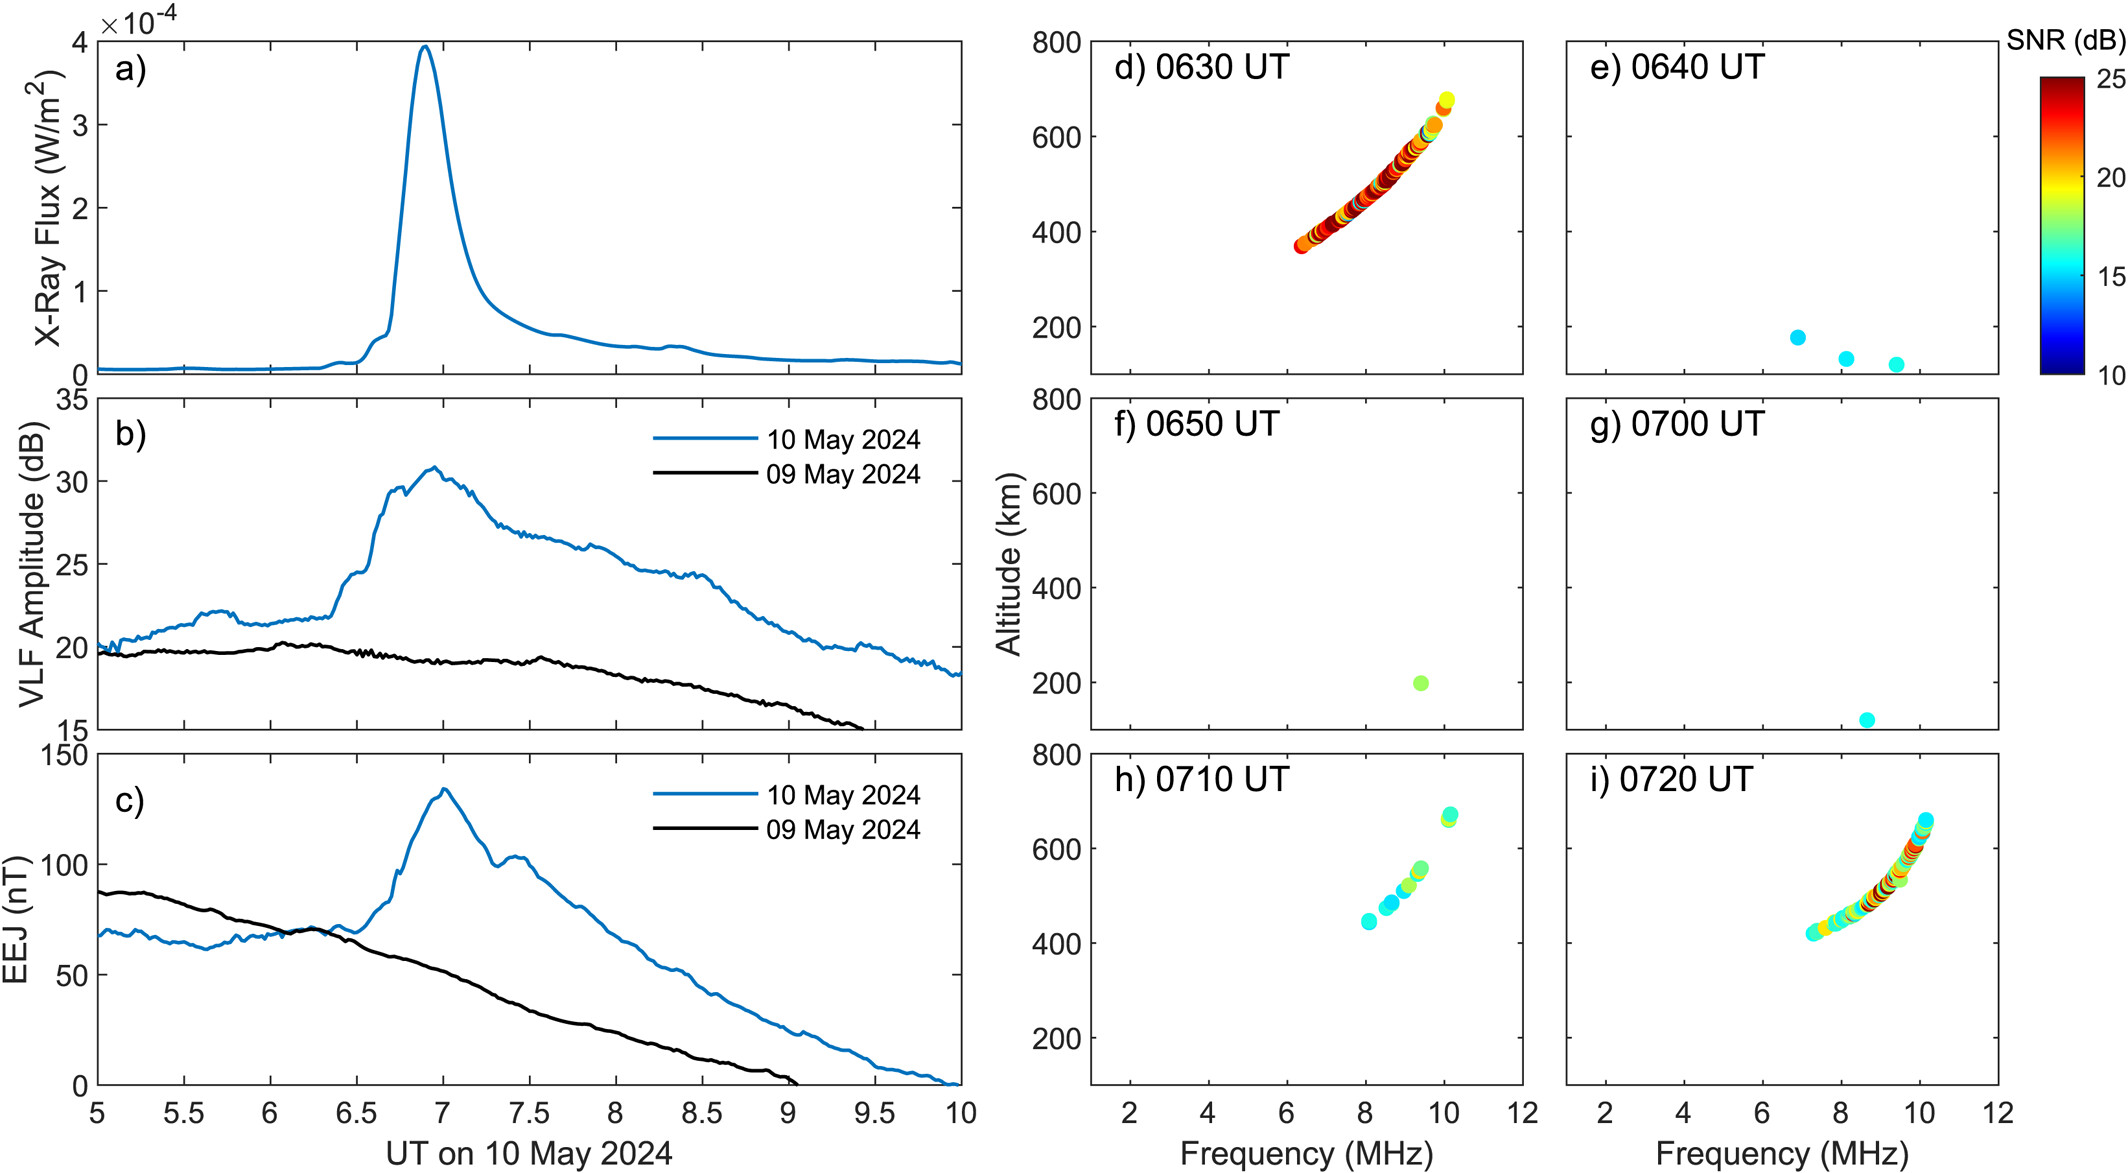

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

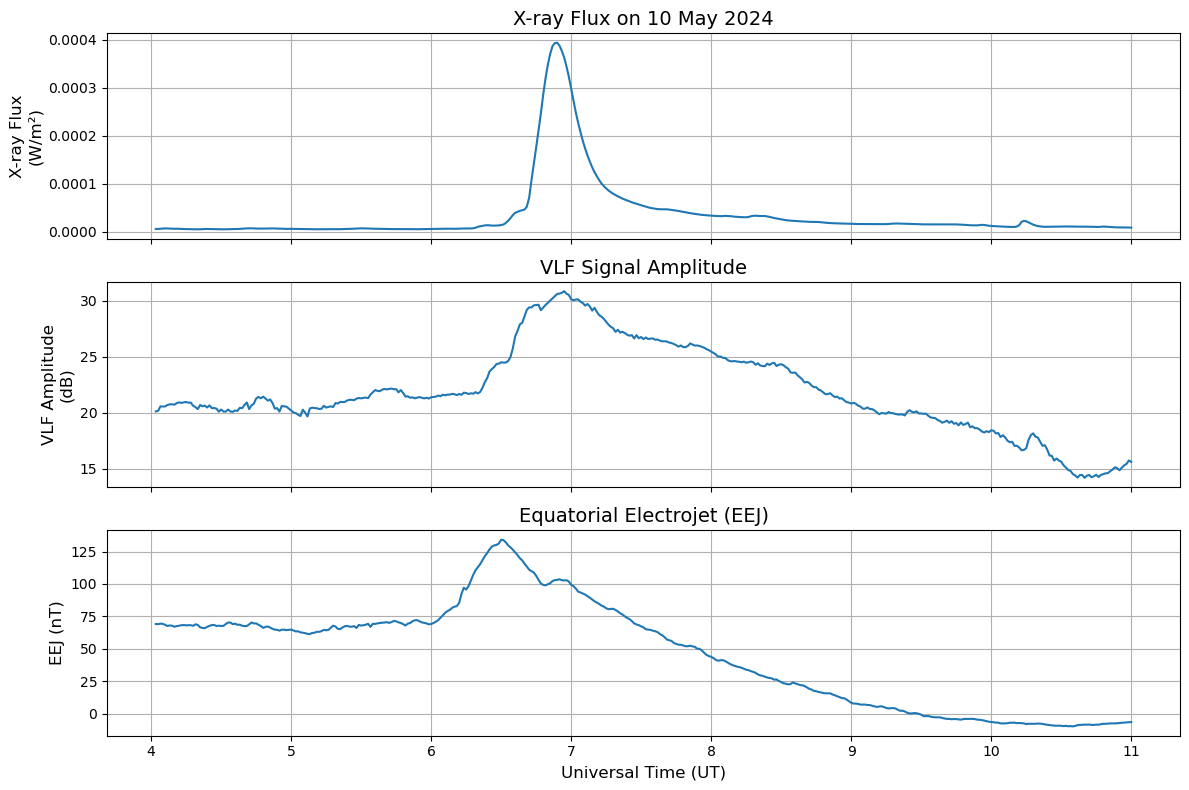

In [3]:
# Recreation of UT on 10 May 2024

# Load file
vlf10_df = pd.read_csv('../data/magnetometer_data/VLF_XrayFlux/Figure_X_10May2024.csv')

# Drop rows with missing values in any relevant columns
plot_vlf10_df = vlf10_df.dropna(subset=['Xray Flux', 'VLF amp', 'EEJ'])

# Set up a multi-panel plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# X-ray Flux
axs[0].plot(plot_vlf10_df['UT'], plot_vlf10_df['Xray Flux'], linewidth=1.5)
axs[0].set_ylabel('X-ray Flux\n(W/m²)', fontsize=12)
axs[0].set_title('X-ray Flux on 10 May 2024', fontsize=14)
axs[0].grid(True)

# VLF Amplitude
axs[1].plot(plot_vlf10_df['UT'], plot_vlf10_df['VLF amp'], linewidth=1.5)
axs[1].set_ylabel('VLF Amplitude\n(dB)', fontsize=12)
axs[1].set_title('VLF Signal Amplitude', fontsize=14)
axs[1].grid(True)

# EEJ
axs[2].plot(plot_vlf10_df['UT'], plot_vlf10_df['EEJ'], linewidth=1.5)
axs[2].set_ylabel('EEJ (nT)', fontsize=12)
axs[2].set_xlabel('Universal Time (UT)', fontsize=12)
axs[2].set_title('Equatorial Electrojet (EEJ)', fontsize=14)
axs[2].grid(True)

plt.tight_layout()
plt.show()


In [4]:
vlf10_df

,UT,Xray Flux,VLF amp,IST_hour,IST_min,UT.1,EEJ
0,4.000000,0.000006,NaN,9,30,4.500000,70.1
1,4.016667,0.000006,NaN,9,31,4.516667,69.5
2,4.033333,0.000006,20.129133,9,32,4.533333,69.1
3,4.050000,0.000006,20.175516,9,33,4.550000,69.0
4,4.066667,0.000006,20.575423,9,34,4.566667,69.4
...,...,...,...,...,...,...,...
416,10.933333,0.000009,15.115286,16,26,11.433333,-7.0
417,10.950000,0.000009,15.318560,16,27,11.450000,-6.9
418,10.966667,0.000009,15.445025,16,28,11.466667,-6.7
419,10.983333,0.000009,15.748605,16,29,11.483333,-6.6


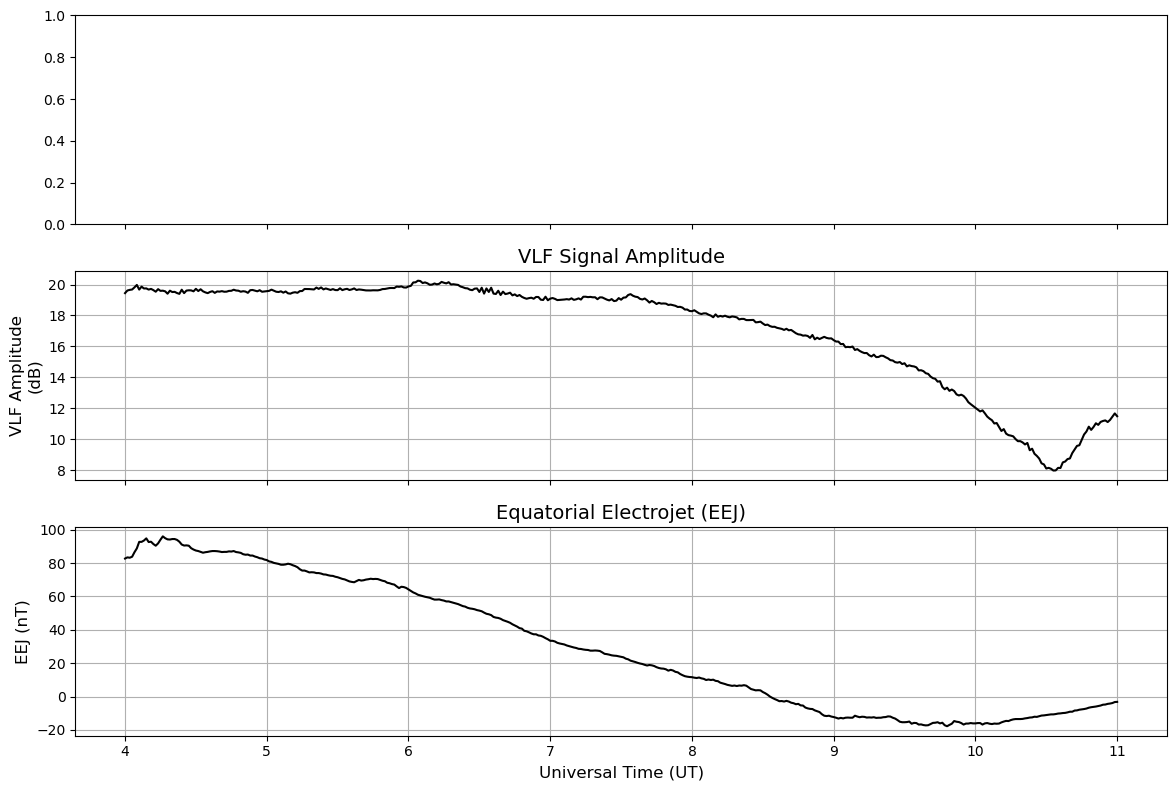

In [5]:
# Make same graph but of 9 May 2024

# Load file
vlf09_df = pd.read_csv('../data/magnetometer_data/VLF_XrayFlux/Figure_X_09May2024.csv')
vlf09_df
# Drop rows with missing values in any relevant columns
plot_vlf09_df = vlf09_df.dropna(subset=['VLF','EEJ'])

# Set up a multi-panel plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# VLF Amplitude
axs[1].plot(plot_vlf09_df['UT'], plot_vlf09_df['VLF'], color='black', linewidth=1.5)
axs[1].set_ylabel('VLF Amplitude\n(dB)', fontsize=12)
axs[1].set_title('VLF Signal Amplitude', fontsize=14)
axs[1].grid(True)

# EEJ
axs[2].plot(plot_vlf09_df['UT'], plot_vlf09_df['EEJ'], color='black', linewidth=1.5)
axs[2].set_ylabel('EEJ (nT)', fontsize=12)
axs[2].set_xlabel('Universal Time (UT)', fontsize=12)
axs[2].set_title('Equatorial Electrojet (EEJ)', fontsize=14)
axs[2].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'sc' is not defined

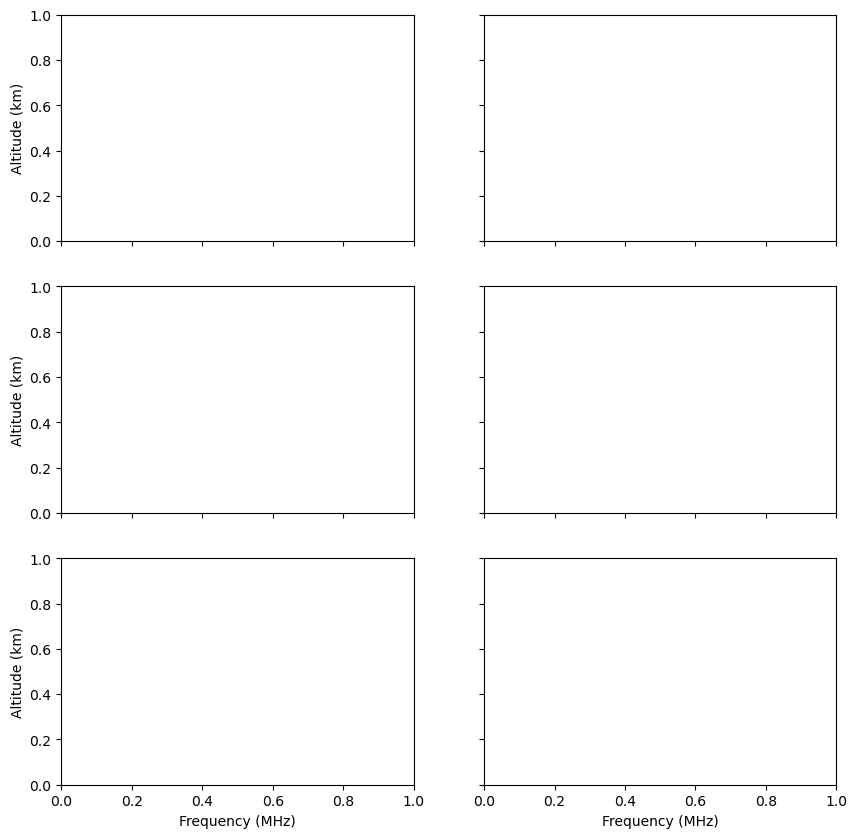

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load all ionogram .txt files
ionogram_files = sorted(glob.glob('../data/magnetometer_data/VIonograms/*.txt'))

# Set up the plot with 3 rows × 2 columns
fig, axs = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)
axs = axs.ravel()

# Time labels for subplot titles
time_labels = ['0630 UT', '0640 UT', '0650 UT', '0700 UT', '0710 UT', '0720 UT']

# Plot each file
for i, filepath in enumerate(ionogram_files):
    df = pd.read_csv(filepath, delim_whitespace=True)

    # Clean invalid or missing values
    df = df[['Freq', 'Ht', 'Amp']].dropna()
    df = df[(df['Freq'] > 0) & (df['Ht'] > 0) & (df['Amp'] > 0)]

    # Plot frequency vs height, colored by amplitude
    sc = axs[i].scatter(df['Freq'], df['Ht'], c=df['Amp'], cmap='jet', vmin=10, vmax=25, s=30, edgecolor='k')
    axs[i].set_title(f'{chr(100 + i)}) {time_labels[i]}', loc='left', fontsize=11)
    axs[i].set_xlim(0, 12)
    axs[i].set_ylim(0, 800)

# Common X and Y labels
for ax in axs[4:]:
    ax.set_xlabel("Frequency (MHz)")
for i in [0, 2, 4]:
    axs[i].set_ylabel("Altitude (km)")

# Add colorbar
cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("SNR (dB)")

plt.tight_layout()
plt.show()
